# Exercise

Training an MLP classifier on the mnist dataset using optuna tracked using MLflow

Hyperparameters to optimize
- Optimizer
- learning rate

Frozen hyperparameters
- batch size
- Number of epochs
- Loss function: cross entropy

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import mlflow
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2


# MLflow config
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('mnistDemo')

mlflow.config.enable_system_metrics_logging()
# mlflow.config.set_system_metrics_sampling_interval(1)

# PyTorch config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'CUDA version: {torch.version.cuda}')
else:
    print('CUDA is not available; using CPU instead.')

CUDA version: 13.0


In [4]:
def to_numpy(t: torch.Tensor) -> NDArray:
    '''Converts a tensor to a numpy array on the CPU'''
    return t.cpu().numpy()

## Data import and organization

In [5]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.1307,), (0.3081,))
])

train_dataset  = datasets.MNIST('data', train=True, transform=transform)
test_dataset  = datasets.MNIST('data', train=False, transform=transform)
MNIST_classes = datasets.MNIST('data').classes

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    num_workers=2,
    pin_memory=True
)

### Data exploration

In [6]:
batch, labels = next(iter(test_loader))

print(MNIST_classes)
print()

print(f'{len(train_loader) = }')
print(f'{len(test_loader) = }')
print(f'{batch.shape = }')
print(f'{labels.shape = }')

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

len(train_loader) = 938
len(test_loader) = 157
batch.shape = torch.Size([64, 1, 28, 28])
labels.shape = torch.Size([64])


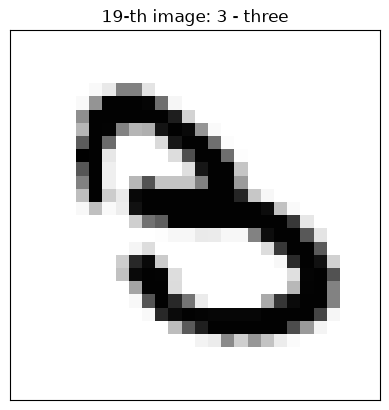

In [7]:
n = 18
im = to_numpy(batch[n, 0, :, :])
MNIST_class = MNIST_classes[labels[n]]

fig, ax = plt.subplots()
ax.imshow(im, cmap='Greys')

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'{n+1}-th image: {MNIST_class}')

plt.show()

## Model and hyperparameter tuning setup

In [8]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.perceptron = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.perceptron(x)
        return logits

model: MLP = MLP().to(device)
loss_fn = nn.CrossEntropyLoss()

In [9]:
fixed_params = {
    'epochs': 5,
    'n_trials': 30,
    'batch_size': 64,
    'model_type': 'MLP',
    'loss_fn': 'cross entropy'
}

def objective(trial: optuna.trial.Trial):
    '''Tune the hyperparameters of an MLP classifier
    
    TODO: Package training and validation logic
    '''
    with mlflow.start_run(nested=True, run_name=f'trial_{trial.number}') as child_run:
        optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam'])
        learning_rate = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

        params = {
            'optimizer': optimizer_name,
            'learning_rate': learning_rate
        }
        optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=learning_rate)
        mlflow.log_params(params)

        # Training loop
        for epoch in range(fixed_params['epochs']):
            model.train()
            train_loss, correct, total = 0, 0, 0  # TODO: Modify code to access
                                                  # other metrics from confusion matrix

            for batch_idx, (data, target) in enumerate(train_loader):
                data, target = data.to(device), target.to(device)

                # Forward pass
                optimizer.zero_grad()
                output = model(data)
                loss = loss_fn(output, target)

                # Backward pass
                loss.backward()
                optimizer.step()

                # Metrics  # TODO: Wrap in a function
                total += target.size(0)
                train_loss += loss.item()

                _, predicted = output.max(1)  # get indices of max element
                                              # for each image in batch
                                              # largest logits <==> largest probas 
                correct += predicted.eq(target).sum().item()  # sum across batch

                # Log batch metrics (every 100 batches)
                if batch_idx % 100 == 0:
                    batch_loss = train_loss / (batch_idx + 1)
                    batch_acc = 100.0 * correct / total
                    mlflow.log_metrics(
                        {'batch_loss': batch_loss, 'batch_accuracy': batch_acc},
                        step=epoch * len(train_loader) + batch_idx
                    )

            # Calculate epoch metrics
            epoch_loss = train_loss / len(train_loader)
            epoch_acc = 100.0 * correct / total

            # Validation (every epoch)  # TODO: Wrap in a function
            model.eval()
            val_loss, val_correct, val_total = 0, 0, 0

            with torch.no_grad():
                for data, target in test_loader:
                    data, target = data.to(device), target.to(device)
                    output = model(data)
                    loss = loss_fn(output, target)

                    val_total += target.size(0)
                    val_loss += loss.item()

                    _, predicted = output.max(1)
                    val_correct += predicted.eq(target).sum().item()
            
            val_loss = val_loss / len(test_loader)
            val_acc = 100.0 * val_correct / val_total
            mlflow.log_metrics(
                {
                    'train_loss': epoch_loss,
                    'train_accuracy': epoch_acc,
                    'val_loss': val_loss,
                    'val_accuracy': val_acc
                },
                step=epoch
            )

            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()


            # Log checkpoint at each epoch end
            signature = mlflow.models.infer_signature(data.cpu().numpy(), model(data).detach().cpu().numpy())
            mlflow.pytorch.log_model(model, name=f'checkpoint_{epoch}', signature=signature, input_example=data)

            print(
                f"Epoch {epoch + 1}/{fixed_params['epochs']}, "
                f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%"
            )

    trial.set_user_attr('run_id', child_run.info.run_id)
    return val_acc

In [10]:
with mlflow.start_run(run_name='study') as run:
    mlflow.log_params(fixed_params)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=fixed_params['n_trials'])
    
    mlflow.log_params(study.best_trial.params)
    mlflow.log_metrics({'best error': study.best_value})
    if best_run_id := study.best_trial.user_attrs.get('run_id'):
        mlflow.log_param('best_child_run_id', best_run_id)

2026/09/08 17:41:17 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
[I 2026-09-08 17:41:17,257] A new study created in memory with name: no-name-0a93d82a-d74f-4ffd-adf3-708131963827
2026/09/08 17:41:17 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Epoch 1/5, Train Loss: 0.3164, Train Acc: 91.15%, Val Loss: 0.2896, Val Acc: 92.45%
Epoch 2/5, Train Loss: 0.2041, Train Acc: 94.43%, Val Loss: 0.2074, Val Acc: 94.76%
Epoch 3/5, Train Loss: 0.1719, Train Acc: 95.43%, Val Loss: 0.1866, Val Acc: 94.54%
Epoch 4/5, Train Loss: 0.1527, Train Acc: 95.90%, Val Loss: 0.1882, Val Acc: 95.68%


2026/09/08 17:42:08 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/08 17:42:08 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-09-08 17:42:08,266] Trial 0 finished with value: 96.29 and parameters: {'optimizer': 'Adam', 'lr': 0.008492536870060742}. Best is trial 0 with value: 96.29.
2026/09/08 17:42:08 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Epoch 5/5, Train Loss: 0.1456, Train Acc: 96.25%, Val Loss: 0.1590, Val Acc: 96.29%
Epoch 1/5, Train Loss: 0.0731, Train Acc: 97.92%, Val Loss: 0.1316, Val Acc: 97.28%
Epoch 2/5, Train Loss: 0.0545, Train Acc: 98.40%, Val Loss: 0.1212, Val Acc: 97.35%
Epoch 3/5, Train Loss: 0.0455, Train Acc: 98.61%, Val Loss: 0.1269, Val Acc: 97.39%
Epoch 4/5, Train Loss: 0.0399, Train Acc: 98.78%, Val Loss: 0.1386, Val Acc: 97.41%


2026/09/08 17:42:58 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/08 17:42:58 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-09-08 17:42:58,007] Trial 1 finished with value: 97.54 and parameters: {'optimizer': 'Adam', 'lr': 0.0010658650360030762}. Best is trial 1 with value: 97.54.
2026/09/08 17:42:58 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


...

2026/09/08 17:47:08 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/08 17:47:08 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-09-08 17:47:08,834] Trial 7 pruned. 
2026/09/08 17:47:08 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Epoch 1/5, Train Loss: 0.0345, Train Acc: 99.09%, Val Loss: 0.1860, Val Acc: 97.63%
Epoch 2/5, Train Loss: 0.0218, Train Acc: 99.36%, Val Loss: 0.2397, Val Acc: 97.54%
Epoch 3/5, Train Loss: 0.0211, Train Acc: 99.38%, Val Loss: 0.1972, Val Acc: 97.64%
Epoch 4/5, Train Loss: 0.0167, Train Acc: 99.50%, Val Loss: 0.2529, Val Acc: 97.24%


2026/09/08 17:47:59 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/08 17:47:59 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-09-08 17:47:59,574] Trial 8 finished with value: 97.46 and parameters: {'optimizer': 'Adam', 'lr': 0.0016150553568674132}. Best is trial 2 with value: 97.63.
2026/09/08 17:47:59 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Epoch 5/5, Train Loss: 0.0200, Train Acc: 99.45%, Val Loss: 0.2426, Val Acc: 97.46%


2026/09/08 17:48:05 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/08 17:48:05 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-09-08 17:48:05,340] Trial 9 pruned. 
2026/09/08 17:48:05 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/09/08 17:48:11 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/08 17:48:11 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-09-08 17:48:11,357] Trial 10 pruned. 
2026/09/08 17:48:11 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/09/08 17:48:17 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/08 17:48:17 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2

In [11]:
print(study.best_trial.number)
print(study.best_trial.value)
print(study.best_trial.params)

2
97.63
{'optimizer': 'Adam', 'lr': 0.0001716325496000385}
